In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("/content/jena_climate_2009_2016.csv")

In [4]:
df.head()

,Date Time,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
0,01.01.2009 00:10:00,996.52,-8.02,265.40,-8.90,93.3,3.33,3.11,0.22,1.94,3.12,1307.75,1.03,1.75,152.3
1,01.01.2009 00:20:00,996.57,-8.41,265.01,-9.28,93.4,3.23,3.02,0.21,1.89,3.03,1309.80,0.72,1.50,136.1
2,01.01.2009 00:30:00,996.53,-8.51,264.91,-9.31,93.9,3.21,3.01,0.20,1.88,3.02,1310.24,0.19,0.63,171.6
3,01.01.2009 00:40:00,996.51,-8.31,265.12,-9.07,94.2,3.26,3.07,0.19,1.92,3.08,1309.19,0.34,0.50,198.0
4,01.01.2009 00:50:00,996.51,-8.27,265.15,-9.04,94.1,3.27,3.08,0.19,1.92,3.09,1309.00,0.32,0.63,214.3


In [5]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 420451 entries, 0 to 420450
Data columns (total 15 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   Date Time        420451 non-null  object 
 1   p (mbar)         420451 non-null  float64
 2   T (degC)         420451 non-null  float64
 3   Tpot (K)         420451 non-null  float64
 4   Tdew (degC)      420451 non-null  float64
 5   rh (%)           420451 non-null  float64
 6   VPmax (mbar)     420451 non-null  float64
 7   VPact (mbar)     420451 non-null  float64
 8   VPdef (mbar)     420451 non-null  float64
 9   sh (g/kg)        420451 non-null  float64
 10  H2OC (mmol/mol)  420451 non-null  float64
 11  rho (g/m**3)     420451 non-null  float64
 12  wv (m/s)         420451 non-null  float64
 13  max. wv (m/s)    420451 non-null  float64
 14  wd (deg)         420451 non-null  float64
dtypes: float64(14), object(1)
memory usage: 48.1+ MB


**discovering nulls and filling it**

In [6]:
df.isna().sum()

,0
Date Time,0
p (mbar),0
T (degC),0
Tpot (K),0
Tdew (degC),0
rh (%),0
VPmax (mbar),0
VPact (mbar),0
VPdef (mbar),0
sh (g/kg),0


In [7]:
df = df.interpolate()
#as our data has nulls between small gaps so that we can filling with interpolation safely

/tmp/ipython-input-4248604237.py:1: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  df = df.interpolate()


In [8]:
df.isnull().sum()

,0
Date Time,0
p (mbar),0
T (degC),0
Tpot (K),0
Tdew (degC),0
rh (%),0
VPmax (mbar),0
VPact (mbar),0
VPdef (mbar),0
sh (g/kg),0


# **feature engineering (circular encoding)**

In [9]:
# 1- adapting date time datatype

df['Date Time'] = pd.to_datetime(df['Date Time'] , format='mixed')

#2- adding col hour , month but using the sin and cos as i want the cyclicity means in month (1 - 12 )are adjecents
# extracting raw hour and month integers
df['hour'] = df['Date Time'].dt.hour
df['month'] = df['Date Time'].dt.month

#For Hour (Max Value = 24)
hours_in_day = 24
df['hour_sin'] = np.sin(df['hour'] * (2. * np.pi / hours_in_day))
df['hour_cos'] = np.cos(df['hour'] * (2. * np.pi / hours_in_day))

#For Month (Max Value = 12)
months_in_year = 12
df['month_sin'] = np.sin(df['month'] * (2. * np.pi / months_in_year))
df['month_cos'] = np.cos(df['month'] * (2. * np.pi / months_in_year))

# Droping the original raw integer columns
df = df.drop(['hour', 'month' ,'Date Time'], axis=1)

In [10]:
df.head(10)

,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg),hour_sin,hour_cos,month_sin,month_cos
0,996.52,-8.02,265.40,-8.90,93.3,3.33,3.11,0.22,1.94,3.12,1307.75,1.03,1.75,152.3,0.000000,1.000000,0.5,0.866025
1,996.57,-8.41,265.01,-9.28,93.4,3.23,3.02,0.21,1.89,3.03,1309.80,0.72,1.50,136.1,0.000000,1.000000,0.5,0.866025
2,996.53,-8.51,264.91,-9.31,93.9,3.21,3.01,0.20,1.88,3.02,1310.24,0.19,0.63,171.6,0.000000,1.000000,0.5,0.866025
3,996.51,-8.31,265.12,-9.07,94.2,3.26,3.07,0.19,1.92,3.08,1309.19,0.34,0.50,198.0,0.000000,1.000000,0.5,0.866025
4,996.51,-8.27,265.15,-9.04,94.1,3.27,3.08,0.19,1.92,3.09,1309.00,0.32,0.63,214.3,0.000000,1.000000,0.5,0.866025
5,996.50,-8.05,265.38,-8.78,94.4,3.33,3.14,0.19,1.96,3.15,1307.86,0.21,0.63,192.7,0.258819,0.965926,0.5,0.866025
6,996.50,-7.62,265.81,-8.30,94.8,3.44,3.26,0.18,2.04,3.27,1305.68,0.18,0.63,166.5,0.258819,0.965926,0.5,0.866025
7,996.50,-7.62,265.81,-8.36,94.4,3.44,3.25,0.19,2.03,3.26,1305.69,0.19,0.50,118.6,0.258819,0.965926,0.5,0.866025
8,996.50,-7.91,265.52,-8.73,93.8,3.36,3.15,0.21,1.97,3.16,1307.17,0.28,0.75,188.5,0.258819,0.965926,0.5,0.866025
9,996.53,-8.43,264.99,-9.34,93.1,3.23,3.00,0.22,1.88,3.02,1309.85,0.59,0.88,185.0,0.258819,0.965926,0.5,0.866025


In [11]:
df.columns

Index(['p (mbar)', 'T (degC)', 'Tpot (K)', 'Tdew (degC)', 'rh (%)',
       'VPmax (mbar)', 'VPact (mbar)', 'VPdef (mbar)', 'sh (g/kg)',
       'H2OC (mmol/mol)', 'rho (g/m**3)', 'wv (m/s)', 'max. wv (m/s)',
       'wd (deg)', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos'],
      dtype='object')

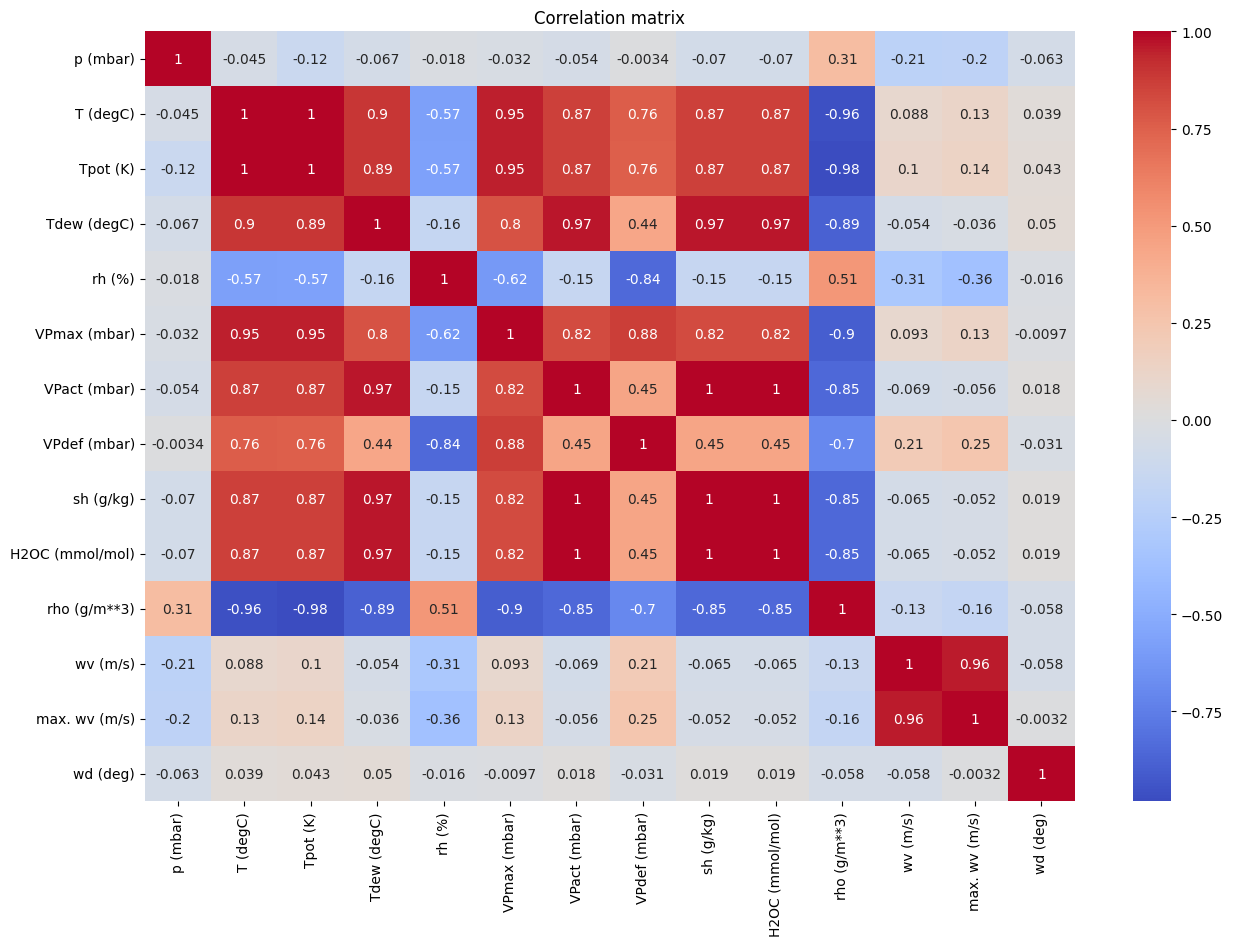

In [12]:
#heatmap to see the correlations
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize= (15 , 10))
corr_mat= df.drop(columns=['hour_sin' , 'hour_cos' , 'month_sin' , 'month_cos']).corr()
sns.heatmap(corr_mat , cmap='coolwarm' , annot = True)
plt.title('Correlation matrix')
plt.show()

## **droping unnessecary columns (really week correlation)**

In [13]:
#dropping the unnessecay cols that don't affect on out target like wd , wv , p (mbar) also the highly correlated features like the same temp but with kilven
abs(corr_mat['T (degC)']).sort_values()
df.drop(columns= ['wd (deg)' ,'p (mbar)' , 'wv (m/s)' , 'max. wv (m/s)' , 'Tpot (K)' ] , inplace = True)

## **splitting before normalization**

In [14]:
#after preprocessing all the data (feature eng , drop unessecary cols ) except the normalizationnnn

#TEMPORAL SPLIT first
train_size = int(len(df) * 0.7)   # 2009-2014
val_size = int(len(df) * 0.15)    # 2015
test_size = len(df) - train_size - val_size  # 2016

train_raw = df.iloc[:train_size].copy()
val_raw = df.iloc[train_size:train_size+val_size].copy()
test_raw = df.iloc[train_size+val_size:].copy()

print(f"Train: {train_raw.index[0]} to {train_raw.index[-1]}")
print(f"Val:   {val_raw.index[0]} to {val_raw.index[-1]}")
print(f"Test:  {test_raw.index[0]} to {test_raw.index[-1]}")


Train: 0 to 294314
Val:   294315 to 357381
Test:  357382 to 420450


## **Normalization using standard scaler but on each col separetly(better results)**

In [15]:
# normalization
#normalizing each col separately and saving the scalers as i want to inverse the scalers while after the prediction

from sklearn.preprocessing import StandardScaler

# Initialize scalers (one per column)
scaler_dict = {}

# 5. Fit scalers ONLY on training data
for column in train_raw.columns:
    scaler = StandardScaler()
    scaler.fit(train_raw[[column]])  # ONLY TRAINING DATA!
    scaler_dict[column] = scaler

# 6. Transform all sets using TRAINING statistics
def scale_data(data_df, scaler_dict):
    scaled_df = pd.DataFrame(index=data_df.index)
    for column in data_df.columns:
        scaler = scaler_dict[column]
        scaled_df[column] = scaler.transform(data_df[[column]]).flatten()
    return scaled_df

train_scaled = scale_data(train_raw, scaler_dict)
val_scaled = scale_data(val_raw, scaler_dict)
test_scaled = scale_data(test_raw, scaler_dict)


### ***Verifying applying normalization approperiatly***

In [16]:
print("\n=== VERIFICATION ===")
print("Training data after scaling (should have ~mean=0, ~std=1):")
for col in ['T (degC)' , 'rh (%)']:
    print(f"  {col}: mean={train_scaled[col].mean():.6f}, std={train_scaled[col].std():.6f}")

print("\nTest data after scaling (using TRAINING statistics):")
for col in ['T (degC)','rh (%)']:
    print(f"  {col}: mean={test_scaled[col].mean():.6f}, std={test_scaled[col].std():.6f}")
    print(f"    (Note: Not exactly 0 and 1, which is CORRECT!)")


=== VERIFICATION ===
Training data after scaling (should have ~mean=0, ~std=1):
  T (degC): mean=0.000000, std=1.000002
  rh (%): mean=0.000000, std=1.000002

Test data after scaling (using TRAINING statistics):
  T (degC): mean=0.050938, std=0.899094
    (Note: Not exactly 0 and 1, which is CORRECT!)
  rh (%): mean=0.065100, std=0.939882
    (Note: Not exactly 0 and 1, which is CORRECT!)


## ***Data Generation***

> (for predicting the temp for the next 12 h using the past 720 h (5 days)



In [17]:
from tensorflow import keras
# Parameters
sequence_length = 720    # 5 days * 144 obs/day (10-min intervals)
sampling_rate = 6        # Take every 6th obs = hourly
batch_size = 256
delay = 72               # Predict 72 steps ahead (72/6 = 12 hours)
target_col = 'T (degC)'  # Your target column


# ***converting into numy array to be appropriate for tensorflow***

In [18]:
train_array = train_scaled.values
val_array = val_scaled.values
test_array = test_scaled.values

# Find temperature column index
target_idx = train_scaled.columns.get_loc(target_col)
print(f"Target column '{target_col}' is at index {target_idx}")

Target column 'T (degC)' is at index 0


## ***function for generation***

In [19]:
def create_multivariate_dataset(
    data_array,
    target_idx,
    sequence_length,
    sampling_rate,
    delay,
    batch_size,
    shuffle=False
):
    # inputs stop early by delay
    data = data_array[:-delay]

    # targets shifted by delay
    targets = data_array[delay:, target_idx]

    dataset = keras.utils.timeseries_dataset_from_array(
        data=data,
        targets=targets,
        sequence_length=sequence_length,
        sampling_rate=sampling_rate,
        sequence_stride=1,
        batch_size=batch_size,
        shuffle=shuffle
    )

    return dataset


## **generation step**

In [20]:

train_dataset = create_multivariate_dataset(
    data_array=train_array,
    target_idx=target_idx,
    sequence_length=sequence_length,
    sampling_rate=sampling_rate,
    delay=delay,
    batch_size=batch_size,
    shuffle=True
)

val_dataset = create_multivariate_dataset(
    data_array=val_array,
    target_idx=target_idx,
    sequence_length=sequence_length,
    sampling_rate=sampling_rate,
    delay=delay,
    batch_size=batch_size,
    shuffle=False
)

test_dataset = create_multivariate_dataset(
    data_array=test_array,
    target_idx=target_idx,
    sequence_length=sequence_length,
    sampling_rate=sampling_rate,
    delay=delay,
    batch_size=batch_size,
    shuffle=False
)


In [21]:
# 3. VERIFICATION

print("\nStep 3: Verifying datasets...")

# Check one batch from each dataset
print("\nTraining dataset:")
for batch_x, batch_y in train_dataset.take(1):
    print(f"  Batch X shape: {batch_x.shape}")  # Should be (batch, seq_len, features)
    print(f"  Batch y shape: {batch_y.shape}")  # Should be (batch,)
    print(f"  Number of features: {batch_x.shape[2]}")
    print(f"  First target (scaled temp): {batch_y[0].numpy():.3f}")

print("\nValidation dataset:")
for batch_x, batch_y in val_dataset.take(1):
    print(f"  Batch X shape: {batch_x.shape}")
    print(f"  Batch y shape: {batch_y.shape}")


Step 3: Verifying datasets...

Training dataset:
  Batch X shape: (256, 720, 13)
  Batch y shape: (256,)
  Number of features: 13
  First target (scaled temp): -0.725

Validation dataset:
  Batch X shape: (256, 720, 13)
  Batch y shape: (256,)


In [22]:
# normalization standard scaler -> done
# outlier threshold , visulaization , nulls -> inspect , clean -> done
# splitting data (720 past , 24 future) -> done
# date generation -> done

In [23]:
for x, y in train_dataset.take(1):
    print("Train batch X shape:", x.shape)
    print("Train batch y shape:", y.shape)

for x, y in val_dataset.take(1):
    print("Val batch X shape:", x.shape)
    print("Val batch y shape:", y.shape)

for x, y in test_dataset.take(1):
    print("Test batch X shape:", x.shape)
    print("Test batch y shape:", y.shape)



Train batch X shape: (256, 720, 13)
Train batch y shape: (256,)
Val batch X shape: (256, 720, 13)
Val batch y shape: (256,)
Test batch X shape: (256, 720, 13)
Test batch y shape: (256,)


#RNN


In [24]:
from tensorflow import keras
from tensorflow.keras import layers

num_features = train_scaled.shape[1]

model = keras.Sequential([
    layers.Input(shape=(None, num_features)),

    layers.SimpleRNN(
        64,
        activation='tanh',
        return_sequences=False
    ),

    layers.Dense(32, activation='relu'),
    layers.Dense(1)   # predicting temperature
])

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 64)             │         4,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,105 (27.75 KB)

 Trainable params: 7,105 (27.75 KB)

 Non-trainable params: 0 (0.00 B)

In [25]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='mse',
    metrics=['mae']
)


In [26]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True
    )
]


In [27]:
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=40,
    callbacks=callbacks
)


Epoch 1/40
1133/1133 ━━━━━━━━━━━━━━━━━━━━ 105s 89ms/step - loss: 0.4350 - mae: 0.5100 - val_loss: 0.3484 - val_mae: 0.4491
Epoch 2/40
1133/1133 ━━━━━━━━━━━━━━━━━━━━ 113s 100ms/step - loss: 0.3469 - mae: 0.4580 - val_loss: 0.3511 - val_mae: 0.4539
Epoch 3/40
1133/1133 ━━━━━━━━━━━━━━━━━━━━ 103s 91ms/step - loss: 0.3530 - mae: 0.4552 - val_loss: 0.3516 - val_mae: 0.4579
Epoch 4/40
1133/1133 ━━━━━━━━━━━━━━━━━━━━ 102s 89ms/step - loss: 0.3372 - mae: 0.4461 - val_loss: 0.4011 - val_mae: 0.4826
Epoch 5/40
1133/1133 ━━━━━━━━━━━━━━━━━━━━ 100s 88ms/step - loss: 0.3716 - mae: 0.4678 - val_loss: 0.3283 - val_mae: 0.4471
Epoch 6/40
1133/1133 ━━━━━━━━━━━━━━━━━━━━ 97s 85ms/step - loss: 0.3522 - mae: 0.4598 - val_loss: 0.3956 - val_mae: 0.4643
Epoch 7/40
1133/1133 ━━━━━━━━━━━━━━━━━━━━ 100s 88ms/step - loss: 0.3555 - mae: 0.4601 - val_loss: 0.3881 - val_mae: 0.4728
Epoch 8/40
1133/1133 ━━━━━━━━━━━━━━━━━━━━ 98s 87ms/step - loss: 0.4012 - mae: 0.4898 - val_loss: 0.3431 - val_mae: 0.4517
Epoch 9/40
1133/1

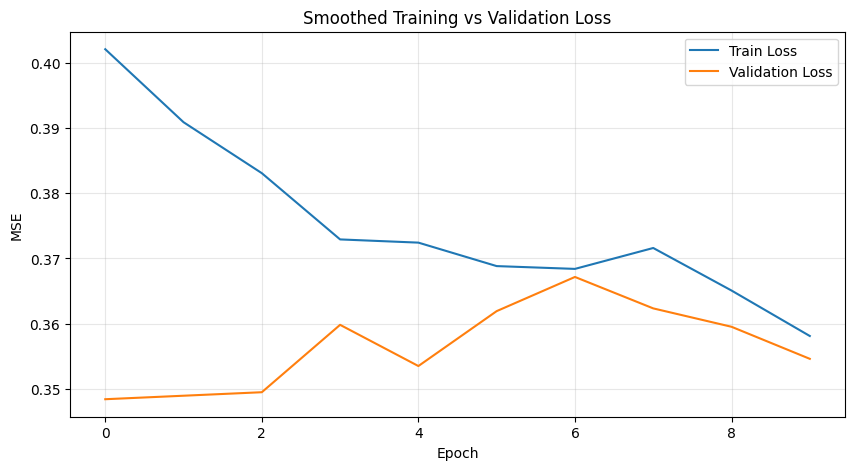

In [34]:
# moving average smoothing
def smooth_curve(points, factor=0.8):
    smoothed = []
    for p in points:
        if smoothed:
            smoothed.append(smoothed[-1] * factor + p * (1 - factor))
        else:
            smoothed.append(p)
    return smoothed

plt.figure(figsize=(10,5))
plt.plot(smooth_curve(history.history['loss']), label='Train Loss')
plt.plot(smooth_curve(history.history['val_loss']), label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.title('Smoothed Training vs Validation Loss')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


In [35]:
model.save("simple_rnn_temperature_model.keras")